# Step 0 — Preprocessing

```
Raw TIFF
  ↓  Normalization   (triangle threshold + 99.9th percentile clipping)
  ↓  Z rescaling     (isotropic voxel via scipy.ndimage.zoom)
  ↓  Noise2Void      (self-supervised 3D denoising, no clean GT needed)
  → output/stack_preprocessed.tif
  → output/preprocess_meta.npz
```

Output은 `step1_tubularity_gpu.ipynb` (Hessian) 또는 `step1_tubularity_oof.ipynb` (OOF)에서 로드됩니다.

In [1]:
# ── Config ──────────────────────────────────────────────────
import os; os.makedirs('output', exist_ok=True)

DATA_PATH   = '../data/FN1_01.tif'            #'../benchmark/data/images/neuron2.tif'
VOXEL_Z     = 1.0    # µm/slice — set manually
VOXEL_XY    = None   # µm/px  — None = auto-detect from TIFF tag (ResolutionUnit=1 only)
                     #          else set manually, e.g. 0.104
DOWNSAMPLE_Z = 1
TARGET_VOXEL_XY_UM = 0.40  # DOWNSAMPLE_XY is auto-computed to keep voxel ≤ this
MAX_XY_PX          = 1024  # XY 최대 해상도 (None = 제한 없음); 크면 DOWNSAMPLE_XY 자동 증가

# ── Normalization ─────────────────────────────────────────────
NORMALIZE_ENABLE     = True   # False = dtype-max scaling만, triangle/percentile 생략
CLIP_LOW_PERCENTILE  = None   # None = triangle 자동 / 숫자 = 하한 percentile (e.g. 10)
CLIP_HIGH_PERCENTILE = 99.9   # 상한 percentile (희소 신호면 99.99 권장)

# ── Noise2Void ────────────────────────────────────────────────
N2V_ENABLE     = False
N2V_TRAIN      = True
N2V_MODEL_DIR  = 'output/n2v_model'
N2V_EPOCHS     = 50
N2V_PATIENCE   = 10
N2V_BATCH_SIZE = 8
N2V_PATCH_XY   = 32
N2V_PATCH_Z    = 8

OUT_TIF  = 'output/FN1_01/stack_preprocessed.tif'
OUT_META = 'output/FN1_01/preprocess_meta.npz'

In [2]:
# ── Imports ─────────────────────────────────────────────────
import numpy as np
import tifffile
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.filters import threshold_triangle
import gc, warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.facecolor': '#111111',
    'axes.facecolor':   '#111111',
    'axes.titlecolor':  'white',
    'text.color':       'white',
})

def show_mip(vol, title='MIP', cmap='gray', vmin=None, vmax=None, ar=1.0):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    kw = dict(cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    axes[0].imshow(vol.max(axis=0), aspect='equal', **kw);  axes[0].set_title('XY (Z-proj)')
    axes[1].imshow(vol.max(axis=1), aspect=ar,     **kw);  axes[1].set_title('XZ (Y-proj)')
    axes[2].imshow(vol.max(axis=2), aspect=ar,     **kw);  axes[2].set_title('YZ (X-proj)')
    for ax in axes: ax.axis('off')
    fig.suptitle(title, fontsize=13); plt.show()

def compare_mip(va, vb, title_a='Before', title_b='After', cmap='gray', ar_a=1.0, ar_b=1.0):
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    for row, (vol, ttl, ar) in enumerate([(va, title_a, ar_a), (vb, title_b, ar_b)]):
        axes[row,0].imshow(vol.max(axis=0), cmap=cmap, aspect='equal')
        axes[row,0].set_title(f'{ttl} - XY')
        axes[row,1].imshow(vol.max(axis=1), cmap=cmap, aspect=ar)
        axes[row,1].set_title(f'{ttl} - XZ')
        axes[row,2].imshow(vol.max(axis=2), cmap=cmap, aspect=ar)
        axes[row,2].set_title(f'{ttl} - YZ')
    for ax in axes.ravel(): ax.axis('off')
    plt.show()

print('Imports ready.')

Imports ready.


---
## 1. Data Loading

In [3]:
# ── Load ────────────────────────────────────────────────────
print(f'Loading: {DATA_PATH}')
stack_raw = tifffile.imread(DATA_PATH)
if stack_raw.ndim == 2:
    stack_raw = stack_raw[np.newaxis]
print(f'  Shape  : {stack_raw.shape}  (Z, Y, X)')
print(f'  dtype  : {stack_raw.dtype}')
print(f'  Memory : {stack_raw.nbytes / 1e9:.2f} GB')
print(f'  Range  : {int(stack_raw.min())} - {int(stack_raw.max())}')

if VOXEL_XY is not None:
    voxel_xy = VOXEL_XY
    print(f'  XY voxel: {voxel_xy:.7f} um/px  (manual)')
else:
    voxel_xy = None
    with tifffile.TiffFile(DATA_PATH) as tif:
        xres  = tif.pages[0].tags.get('XResolution')
        runit = tif.pages[0].tags.get('ResolutionUnit')
        if xres is not None:
            val  = xres.value
            res  = (val[0] / val[1]) if isinstance(val, tuple) and val[1] != 0 else float(val)
            unit = runit.value if runit is not None else 2
            # unit=1: no unit (µm);  unit=2: inch (DPI — unreliable, skip)
            if res > 0 and unit == 1:
                voxel_xy = 1.0 / res
    if voxel_xy is None or voxel_xy <= 0:
        voxel_xy = 1.0
        print('WARNING: XY voxel size not found in TIFF. Set VOXEL_XY in Config.')
    else:
        print(f'  XY voxel: {voxel_xy:.7f} um/px  (from TIFF tag)')

# Validate VOXEL_Z — only manually set parameter; 2× error distorts entire Z axis
assert 0.1 <= VOXEL_Z <= 10.0, (
    f'VOXEL_Z={VOXEL_Z} out of plausible range [0.1, 10.0] µm/slice. '
    'Check your acquisition settings.'
)
if VOXEL_Z < 0.5:
    print(f'WARNING: VOXEL_Z={VOXEL_Z} µm very small — confirm slice thickness')
if VOXEL_Z > 3.0:
    print(f'WARNING: VOXEL_Z={VOXEL_Z} µm large — Z rescaling will expand volume significantly')
print(f'  Z  voxel: {VOXEL_Z:.4f} um/slice')
print(f'  Anisotropy (Z/XY): {VOXEL_Z / voxel_xy:.2f}x')

# ── Auto-compute DOWNSAMPLE_XY ───────────────────────────────
_, raw_Y, raw_X = stack_raw.shape
ds_voxel = max(1, int(TARGET_VOXEL_XY_UM / voxel_xy))
ds_size  = max(1, int(np.ceil(max(raw_Y, raw_X) / MAX_XY_PX))) if MAX_XY_PX else 1
DOWNSAMPLE_XY = max(ds_voxel, ds_size)
reason = []
if ds_voxel >= ds_size: reason.append(f'voxel target ≤{TARGET_VOXEL_XY_UM}µm')
if ds_size  >= ds_voxel: reason.append(f'MAX_XY_PX={MAX_XY_PX}')
print(f'  DOWNSAMPLE_XY auto: {DOWNSAMPLE_XY}  '
      f'(by: {" & ".join(reason)}  '
      f'raw={voxel_xy:.4f}µm → ds={voxel_xy*DOWNSAMPLE_XY:.4f}µm  '
      f'{raw_Y}×{raw_X} → {raw_Y//DOWNSAMPLE_XY}×{raw_X//DOWNSAMPLE_XY}px)')

Loading: ../data/FN1_01.tif
  Shape  : (364, 1992, 1980)  (Z, Y, X)
  dtype  : uint16
  Memory : 2.87 GB
  Range  : 381 - 15508
  XY voxel: 0.1710000 um/px  (from TIFF tag)
  Z  voxel: 1.0000 um/slice
  Anisotropy (Z/XY): 5.85x
  DOWNSAMPLE_XY auto: 2  (by: voxel target ≤0.4µm & MAX_XY_PX=1024  raw=0.1710µm → ds=0.3420µm  1992×1980 → 996×990px)


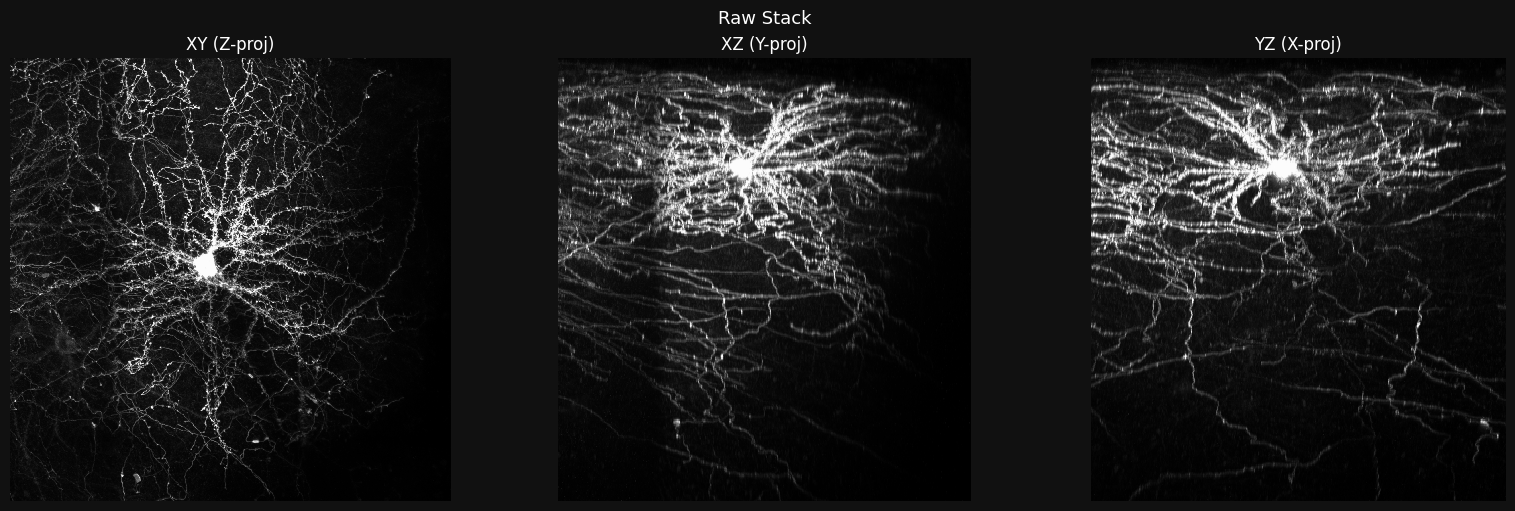

In [4]:
show_mip(stack_raw, title='Raw Stack', ar=VOXEL_Z / voxel_xy)

---
## 2. Normalization

- **하한**: `threshold_triangle` - 배경/신호 경계 자동 탐지
- **상한**: 99.9th percentile - 핫픽셀 제거
- 결과: float32 [0, 1]

After downsample : (364, 996, 990)  aniso=2.92x
Full range  : 381 - 15441
Clip range  : 1292.8 - 4482.0  (triangle / 99.9th pct)
Normalized  : 0.0000 - 1.0000


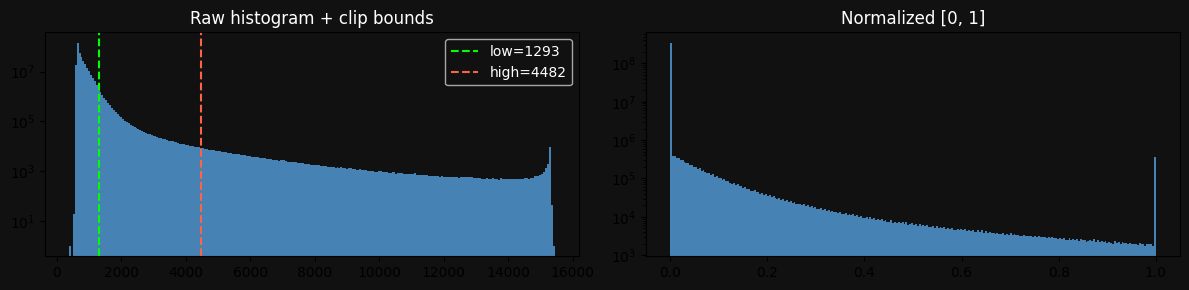

In [5]:
# ── Downsample → float32 → Normalize ────────────────────────
stack_ds = stack_raw[::DOWNSAMPLE_Z, ::DOWNSAMPLE_XY, ::DOWNSAMPLE_XY]
vxy   = voxel_xy * DOWNSAMPLE_XY
vz    = VOXEL_Z  * DOWNSAMPLE_Z
aniso = vz / vxy
print(f'After downsample : {stack_ds.shape}  aniso={aniso:.2f}x')

stack_f = stack_ds.astype(np.float32)
print(f'Full range  : {stack_f.min():.0f} - {stack_f.max():.0f}')

if NORMALIZE_ENABLE:
    p_low  = float(np.percentile(stack_f, CLIP_LOW_PERCENTILE)) if CLIP_LOW_PERCENTILE is not None \
             else float(threshold_triangle(stack_f))
    p_high = float(np.percentile(stack_f, CLIP_HIGH_PERCENTILE))
    low_label  = f'{CLIP_LOW_PERCENTILE}th pct' if CLIP_LOW_PERCENTILE is not None else 'triangle'
    print(f'Clip range  : {p_low:.1f} - {p_high:.1f}  ({low_label} / {CLIP_HIGH_PERCENTILE}th pct)')
    stack_norm = np.clip(stack_f, p_low, p_high)
    stack_norm = (stack_norm - p_low) / (p_high - p_low)
else:
    dtype_max = float(np.iinfo(stack_ds.dtype).max) if np.issubdtype(stack_ds.dtype, np.integer) else 1.0
    p_low, p_high = 0.0, dtype_max
    stack_norm = stack_f / dtype_max
    print(f'Normalization skipped — scaled by 1/{dtype_max:.0f}')

del stack_f; gc.collect()
print(f'Normalized  : {stack_norm.min():.4f} - {stack_norm.max():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].hist(stack_ds.ravel(), bins=256, color='steelblue', log=True)
ax[0].axvline(p_low,  color='lime',   linestyle='--', label=f'low={p_low:.0f}')
ax[0].axvline(p_high, color='tomato', linestyle='--', label=f'high={p_high:.0f}')
ax[0].legend(); ax[0].set_title('Raw histogram + clip bounds')
ax[1].hist(stack_norm.ravel(), bins=256, color='steelblue', log=True)
ax[1].set_title('Normalized [0, 1]')
plt.tight_layout(); plt.show()

---
## 3. Z Rescaling (Isotropic)

Z 방향 voxel 크기를 XY와 맞춰 isotropic volume 생성.  
anisotropy < 1.2 이면 생략.

Rescaling Z by 2.92x ...
  Before : (364, 996, 990)
  After  : (1064, 996, 990)
  Memory : 4.20 GB
Isotropic voxel size: 0.3420 um


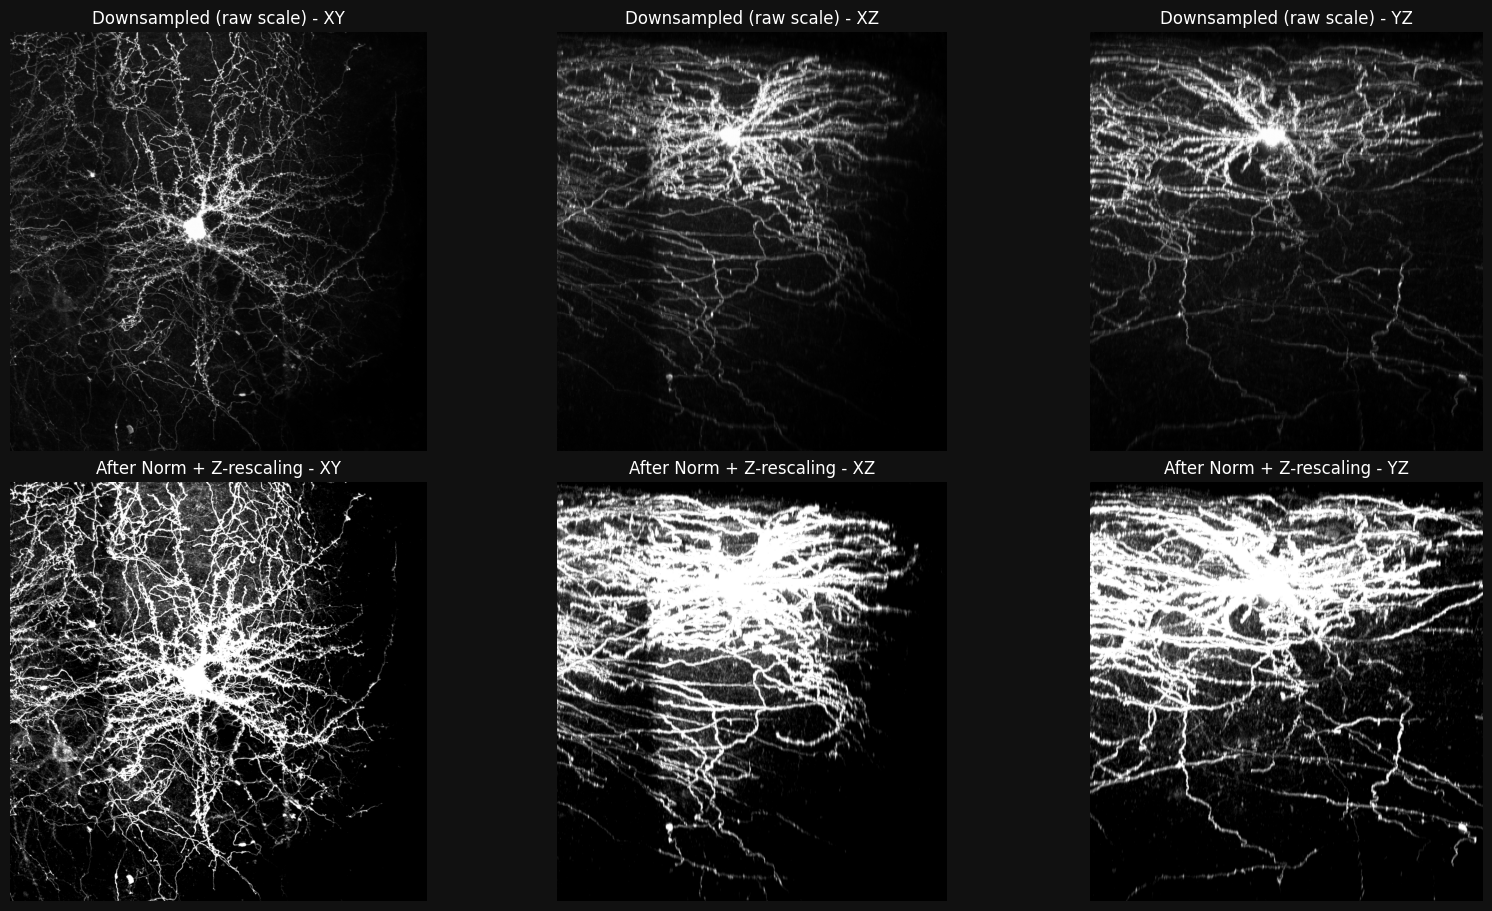

In [6]:
# ── Isotropic Z-rescaling ────────────────────────────────────
if aniso > 1.2:
    print(f'Rescaling Z by {aniso:.2f}x ...')
    stack_iso = ndimage.zoom(stack_norm, (aniso, 1.0, 1.0), order=1, prefilter=False)
    voxel_iso = vxy
    print(f'  Before : {stack_norm.shape}')
    print(f'  After  : {stack_iso.shape}')
    print(f'  Memory : {stack_iso.nbytes / 1e9:.2f} GB')
else:
    stack_iso = stack_norm.copy()
    voxel_iso = vxy
    print('Near-isotropic - Z rescaling skipped.')

del stack_norm; gc.collect()
print(f'Isotropic voxel size: {voxel_iso:.4f} um')

compare_mip(stack_ds.astype(np.float32) / (stack_ds.max() + 1e-8), stack_iso,
            title_a='Downsampled (raw scale)', title_b='After Norm + Z-rescaling',
            ar_a=aniso, ar_b=1.0)

---
## 4. Noise2Void (Self-supervised Denoising)

N2V는 clean reference image 없이 단일 volume만으로 학습하는 self-supervised denoiser.  
Blind-spot network: 각 픽셀을 주변 랜덤 픽셀로 예측 → Poisson/Gaussian noise 제거.

설치 (처음 한 번만):
```bash
pip install n2v
```

- `N2V_TRAIN = True` : 해당 데이터셋으로 학습 + 저장
- `N2V_TRAIN = False`: `N2V_MODEL_DIR`에서 기저장 모델 로드

In [7]:
# ── N2V: check install ───────────────────────────────────────
import os, platform

if not N2V_ENABLE:
    N2V_AVAILABLE = False
    print('N2V_ENABLE=False -> N2V 생략')
else:
    try:
        from n2v.models import N2VConfig, N2V
        from n2v.internals.N2V_DataGenerator import N2V_DataGenerator
        import tensorflow as tf
        if platform.system() == 'Darwin':
            # CUDA_VISIBLE_DEVICES는 Metal을 못 막음 -> TF API로 직접 비활성화
            tf.config.set_visible_devices([], 'GPU')
        print(f'n2v ready  | TF {tf.__version__}')
        print(f'Devices: {tf.config.list_logical_devices()}')
        N2V_AVAILABLE = True
    except ImportError as e:
        print(f'n2v not installed: {e}')
        N2V_AVAILABLE = False


N2V_ENABLE=False -> N2V 생략


In [8]:
# ── N2V: Training ────────────────────────────────────────────
if N2V_AVAILABLE and N2V_TRAIN:
    datagen = N2V_DataGenerator()
    vol_n2v = stack_iso[np.newaxis, ..., np.newaxis]  # (1, Z, Y, X, 1)
    patches = datagen.generate_patches_from_list(
        [vol_n2v],
        shape=(N2V_PATCH_Z, N2V_PATCH_XY, N2V_PATCH_XY),
    )
    n_val   = max(1, int(len(patches) * 0.1))
    X_train = patches[n_val:]
    X_val   = patches[:n_val]
    print(f'Patches: train={len(X_train)}  val={len(X_val)}  shape={X_train.shape[1:]}')

    config = N2VConfig(
        X_train,
        unet_kern_size          = 3,
        train_steps_per_epoch   = 400,  # 고정: batch_size와 무관하게 epoch 길이 제어
        train_epochs            = N2V_EPOCHS,
        train_loss              = 'mse',
        batch_norm              = False,   # Metal GPU: FusedBatchNorm은 5D 미지원
        train_batch_size        = N2V_BATCH_SIZE,
        n2v_perc_pix            = 0.198,
        n2v_patch_shape         = (N2V_PATCH_Z, N2V_PATCH_XY, N2V_PATCH_XY),
        n2v_manipulator         = 'uniform_withCP',
        n2v_neighborhood_radius = 3,
        unet_n_depth            = 1,
        unet_n_first            = 32,
    )
    model = N2V(config, 'n2v_3d', basedir=N2V_MODEL_DIR)

    # EarlyStopping: prepare_for_training() 후 callbacks 리스트에 직접 추가
    from tensorflow.keras.callbacks import EarlyStopping
    model.prepare_for_training()
    model.callbacks.append(EarlyStopping(
        monitor='val_loss',
        patience=N2V_PATIENCE,
        restore_best_weights=True,
        verbose=1,
    ))
    history = model.train(X_train, X_val)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(history.history['loss'],     label='train')
    ax[0].plot(history.history['val_loss'], label='val')
    ax[0].set_title('Loss'); ax[0].legend()
    ax[1].plot(history.history.get('mse', []), label='train mse')
    ax[1].set_title('MSE')
    plt.tight_layout(); plt.show()
    print(f'Stopped at epoch {len(history.history["loss"])} / {N2V_EPOCHS}')
    print(f'Model saved -> {N2V_MODEL_DIR}/n2v_3d/')

elif N2V_AVAILABLE and not N2V_TRAIN:
    model = N2V(config=None, name='n2v_3d', basedir=N2V_MODEL_DIR)
    print(f'Loaded model from {N2V_MODEL_DIR}/n2v_3d/')

else:
    print('N2V skipped.')


N2V skipped.


In [9]:
# ── N2V: Prediction ─────────────────────────────────────────
if N2V_AVAILABLE:
    import time
    print('Denoising ...')
    t0 = time.time()
    stack_denoised = model.predict(stack_iso, axes='ZYX')
    stack_denoised = np.clip(stack_denoised, 0.0, 1.0).astype(np.float32)
    print(f'Done in {time.time()-t0:.1f}s')
    print(f'Range: {stack_denoised.min():.4f} - {stack_denoised.max():.4f}')

    # Slice comparison
    z_mid = stack_iso.shape[0] // 2
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(stack_iso[z_mid],      cmap='gray', vmin=0, vmax=1)
    axes[0].set_title(f'Before N2V  (z={z_mid})')
    axes[1].imshow(stack_denoised[z_mid], cmap='gray', vmin=0, vmax=1)
    axes[1].set_title(f'After N2V   (z={z_mid})')
    for ax in axes: ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    stack_denoised = stack_iso
    print('Using stack_iso (N2V skipped).')

Using stack_iso (N2V skipped).


---
## 5. Save

In [10]:
# ── Save ────────────────────────────────────────────────────
tifffile.imwrite(OUT_TIF, stack_denoised)
np.savez(OUT_META,
    voxel_iso = np.float32(voxel_iso),
    p_low     = np.float32(p_low),
    p_high    = np.float32(p_high),
    aniso     = np.float32(aniso),
    n2v_used  = np.bool_(N2V_AVAILABLE),
)

print(f'Saved: {OUT_TIF}  {stack_denoised.shape}  {stack_denoised.dtype}')
print(f'Saved: {OUT_META}')
print()
print('Summary')
print(f'  voxel_iso  : {voxel_iso:.4f} um')
print(f'  clip range : {p_low:.1f} - {p_high:.1f}  (raw units)')
print(f'  anisotropy : {aniso:.2f}x  (Z/XY before rescaling)')
print(f'  N2V used   : {N2V_AVAILABLE}')
print(f'  Output     : {stack_denoised.shape}  float32 [0,1]')

Saved: output/FN1_01/stack_preprocessed.tif  (1064, 996, 990)  float32
Saved: output/FN1_01/preprocess_meta.npz

Summary
  voxel_iso  : 0.3420 um
  clip range : 1292.8 - 4482.0  (raw units)
  anisotropy : 2.92x  (Z/XY before rescaling)
  N2V used   : False
  Output     : (1064, 996, 990)  float32 [0,1]


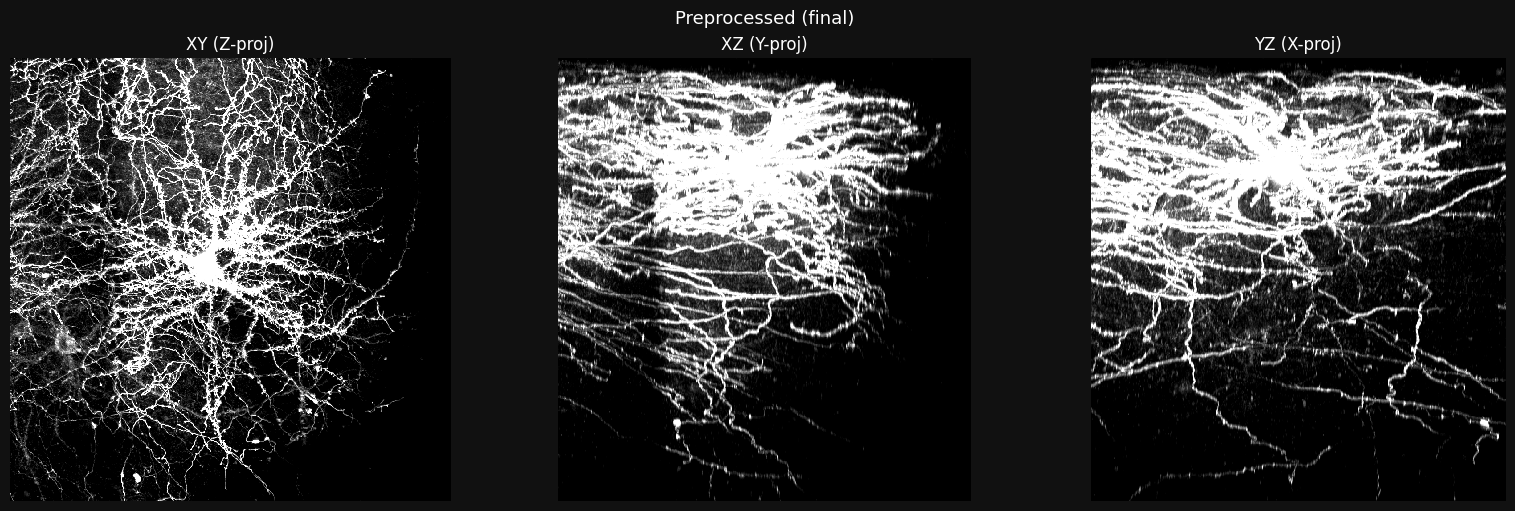

In [11]:
show_mip(stack_denoised, title='Preprocessed (final)', cmap='gray', ar=1.0)